# Étape 5c - Diagnostic du modèle retenu et évaluation finale

L'étape 5b a choisi le modèle livré, en validation croisée groupée et avant toute
ouverture du jeu de test. Cette étape :

1. **diagnostique** ce modèle en validation croisée groupée, sur le seul apprentissage :
   résidus, importance des variables, erreurs par groupe, robustesse temporelle ;
2. **ouvre le jeu de test une seule fois**, en section 6, pour mesurer le score final ;
3. **livre** la pipeline complète et démontre une prédiction sur une donnée brute.

**La règle du jeu de test.** Le test n'est construit que dans la cellule de la section 6,
qui ne fait que mesurer. Aucune analyse ne le réutilise ensuite : tout ce qui sert à
comprendre le modèle (résidus, importances, erreurs par groupe) est calculé avant, sur des
prédictions hors pli, et le contrôle de rechargement porte sur des lignes d'apprentissage.

> **Révision du protocole** (voir [étape 10](../etapes/étape_10_revision.md)). Dans la
> première version, ces analyses étaient faites à l'étape 5 sur le jeu de test, après la
> mesure finale. Elles sont désormais faites en validation croisée, et le test, devenu un
> ensemble de formations jamais vues, ne sert qu'une fois.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))
from modeles.protocole import (CODE_SISE, CODE_UAI, COLONNES_ENTREE, CV, FEATURES,
                               POURSUIVANTS, SORTANTS, TARGET, creer_pipeline, decouper,
                               identifiant_formation)

DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase3_final.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'
MODEL_PATH = PROJECT_PATH / 'modeles'
CHOIX_PATH = MODEL_PATH / 'choix_modele.json'
FICHIER_MODELE = MODEL_PATH / 'modele_final.joblib'

COULEUR = '#2f6f9f'
COULEUR_ALT = '#d1793c'
COULEUR_NEUTRE = '#9aa5ad'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 9,
})

SOURCE_DONNEES = ('Source : InserSup, millésime 2026_S1 · promotions 2019 à 2024 · '
                  'MESR, Licence Ouverte Etalab')


def annoter_source(texte=SOURCE_DONNEES):
    """Appose la source et la période en pied de figure, juste avant l'export."""
    plt.gcf().text(0.995, -0.012, texte, ha='right', va='top',
                   fontsize=7, color=COULEUR_NEUTRE, style='italic')


def mesurer(vraies_valeurs, valeurs_predites):
    """MAE, RMSE et R², dans l'unité de la cible."""
    return {
        'MAE': round(mean_absolute_error(vraies_valeurs, valeurs_predites), 3),
        'RMSE': round(mean_squared_error(vraies_valeurs, valeurs_predites) ** 0.5, 3),
        'R²': round(r2_score(vraies_valeurs, valeurs_predites), 3),
    }


# Le modèle a été choisi à l'étape 5b, avant que le test existe.
choix = json.loads(CHOIX_PATH.read_text(encoding='utf-8'))
CLASSES = {'RandomForestRegressor': RandomForestRegressor,
           'HistGradientBoostingRegressor': HistGradientBoostingRegressor}
modele_retenu = CLASSES[choix['classe']](random_state=42, **choix['parametres'])
NOM_MODELE = choix['modele']

df = pd.read_csv(DATA_PATH, dtype={CODE_SISE: str})
index_train, index_test = decouper(df)
X_train = df.loc[index_train, COLONNES_ENTREE]
y_train = df.loc[index_train, TARGET]
groupes_train = identifiant_formation(df.loc[index_train])

print(f'Modèle retenu à l\'étape 5b : {NOM_MODELE}')
print(f'Hyperparamètres : {choix["parametres"]}')
print(f'Apprentissage : {len(X_train)} lignes, {groupes_train.nunique()} formations')
print(f'Test : {len(index_test)} lignes, fermé jusqu\'à la section 6')

Modèle retenu à l'étape 5b : Gradient boosting
Hyperparamètres : {'max_iter': 400, 'early_stopping': False, 'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}
Apprentissage : 13718 lignes, 3958 formations
Test : 3347 lignes, fermé jusqu'à la section 6


## 1. Prédictions hors pli et importance par pli

Une seule boucle sur les cinq plis groupés produit tout ce qui sert au diagnostic. Pour
chaque pli, le modèle est entraîné sur les quatre autres, puis :

- il prédit les lignes du pli tenu à l'écart, ce qui donne une **prédiction hors pli**
  pour chaque ligne d'apprentissage, par un modèle qui n'a vu aucune promotion de sa
  formation ;
- on mesure l'**importance par permutation** sur ce même pli : de combien la RMSE se
  dégrade quand on mélange une variable. La permutation porte sur les 18 variables que
  voit le modèle, agrégats compris, c'est-à-dire après l'étape `agregats` de la pipeline.

Les importances sont moyennées sur les cinq plis, et leur écart-type dit si le classement
est stable.

In [2]:
oof = np.zeros(len(y_train))
importances_par_pli = []
for numero, (positions_ajuste, positions_mesure) in enumerate(
        CV.split(X_train, y_train, groups=groupes_train), start=1):
    pipeline = creer_pipeline(modele_retenu)
    pipeline.fit(X_train.iloc[positions_ajuste], y_train.iloc[positions_ajuste])
    X_mesure = X_train.iloc[positions_mesure]
    y_mesure = y_train.iloc[positions_mesure]
    oof[positions_mesure] = pipeline.predict(X_mesure)

    X_mesure_modele = pipeline.named_steps['agregats'].transform(X_mesure)[FEATURES]
    resultat = permutation_importance(pipeline[1:], X_mesure_modele, y_mesure, n_repeats=3,
                                      random_state=42, n_jobs=1,
                                      scoring='neg_root_mean_squared_error')
    importances_par_pli.append(pd.Series(resultat.importances_mean, index=FEATURES,
                                         name=f'pli {numero}'))

vraies = y_train.to_numpy()
residus = vraies - oof
importances = pd.concat(importances_par_pli, axis=1)
print(f'{NOM_MODELE}, validation croisée groupée, prédictions hors pli :')
for metrique, valeur in mesurer(vraies, oof).items():
    print(f'  {metrique} = {valeur}')

Gradient boosting, validation croisée groupée, prédictions hors pli :
  MAE = 10.084
  RMSE = 13.097
  R² = 0.5


## 2. Résidus

Les résidus sont calculés sur les prédictions hors pli de l'apprentissage : chaque point est
une formation prédite par un modèle qui ne l'avait jamais vue.

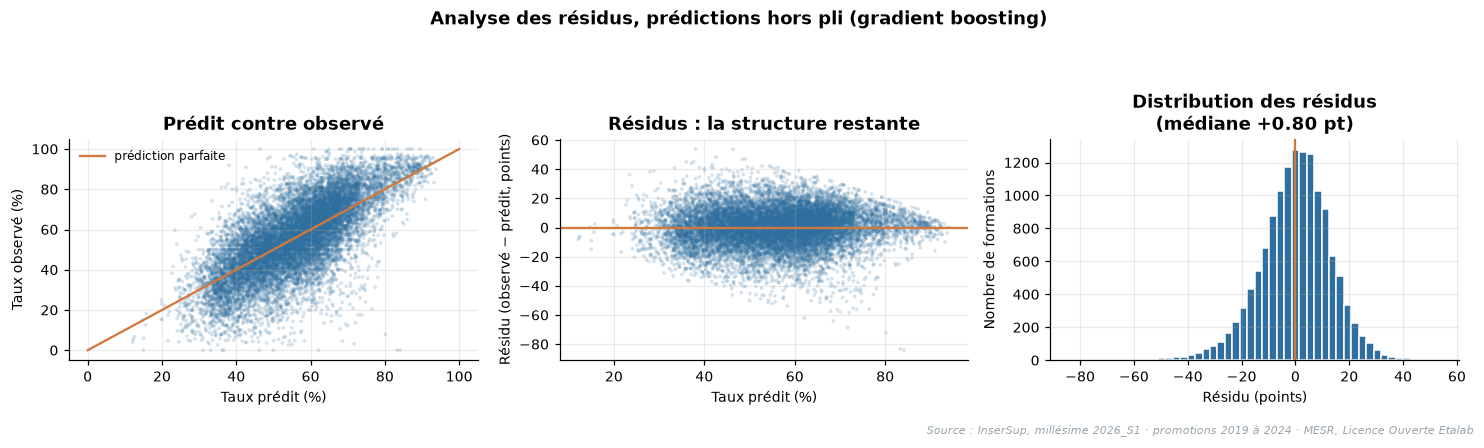

Résidu moyen : +0.127 point · écart-type : 13.10 points
Pente résidus ~ prédictions : +0.036
Pente résidus ~ valeurs observées : +0.516
Taux observés ≥ 85 % : résidu moyen +15.0 point
Taux observés ≤ 25 % : résidu moyen -23.2 point


In [3]:
figure, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axes[0].scatter(oof, vraies, s=6, alpha=0.2, color=COULEUR, edgecolor='none')
limites = [0, 100]
axes[0].plot(limites, limites, color=COULEUR_ALT, linewidth=1.5, label='prédiction parfaite')
axes[0].set_xlabel('Taux prédit (%)')
axes[0].set_ylabel('Taux observé (%)')
axes[0].set_title('Prédit contre observé')
axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(oof, residus, s=6, alpha=0.2, color=COULEUR, edgecolor='none')
axes[1].axhline(0, color=COULEUR_ALT, linewidth=1.5)
axes[1].set_xlabel('Taux prédit (%)')
axes[1].set_ylabel('Résidu (observé − prédit, points)')
axes[1].set_title('Résidus : la structure restante')

axes[2].hist(residus, bins=50, color=COULEUR, edgecolor='white')
axes[2].axvline(0, color=COULEUR_ALT, linewidth=1.5)
axes[2].set_xlabel('Résidu (points)')
axes[2].set_ylabel('Nombre de formations')
axes[2].set_title(f'Distribution des résidus\n(médiane {np.median(residus):+.2f} pt)')

figure.suptitle(f'Analyse des résidus, prédictions hors pli ({NOM_MODELE.lower()})',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig14_residus.png')
plt.show()

pente = np.polyfit(oof, residus, 1)[0]
pente_observee = np.polyfit(vraies, residus, 1)[0]
print(f'Résidu moyen : {residus.mean():+.3f} point · écart-type : {residus.std():.2f} points')
print(f'Pente résidus ~ prédictions : {pente:+.3f}')
print(f'Pente résidus ~ valeurs observées : {pente_observee:+.3f}')
print(f'Taux observés ≥ 85 % : résidu moyen {residus[vraies >= 85].mean():+.1f} point')
print(f'Taux observés ≤ 25 % : résidu moyen {residus[vraies <= 25].mean():+.1f} point')

**Lecture des résidus.** Le résidu moyen est quasi nul (+0,13 point) : le modèle ne se
trompe pas systématiquement dans un sens. Mais le nuage « prédit contre observé » reste
aplati par rapport à la diagonale. Rapportés aux valeurs observées, les résidus ont une
pente de +0,52 : sur les formations qui insèrent à 85 % ou plus, le modèle sous-estime en
moyenne de 15 points ; sur celles qui insèrent à 25 % ou moins, il surestime de 23 points.

C'est le comportement attendu d'un modèle d'ensemble, dont la prédiction est une moyenne
attirée vers le centre de la distribution. La conséquence doit être annoncée : **le modèle
est le moins fiable exactement sur les formations extrêmes**, celles qui insèrent très bien
ou très mal, souvent celles qui intéressent le plus un responsable pédagogique.

## 3. Ce que le modèle a appris

L'importance par permutation est la seule mesure retenue, pour deux raisons : elle est
comparable d'un modèle à l'autre, alors que l'importance par impureté n'existe que pour
les forêts, et elle mesure une dégradation réelle du score plutôt qu'un usage interne au
modèle.

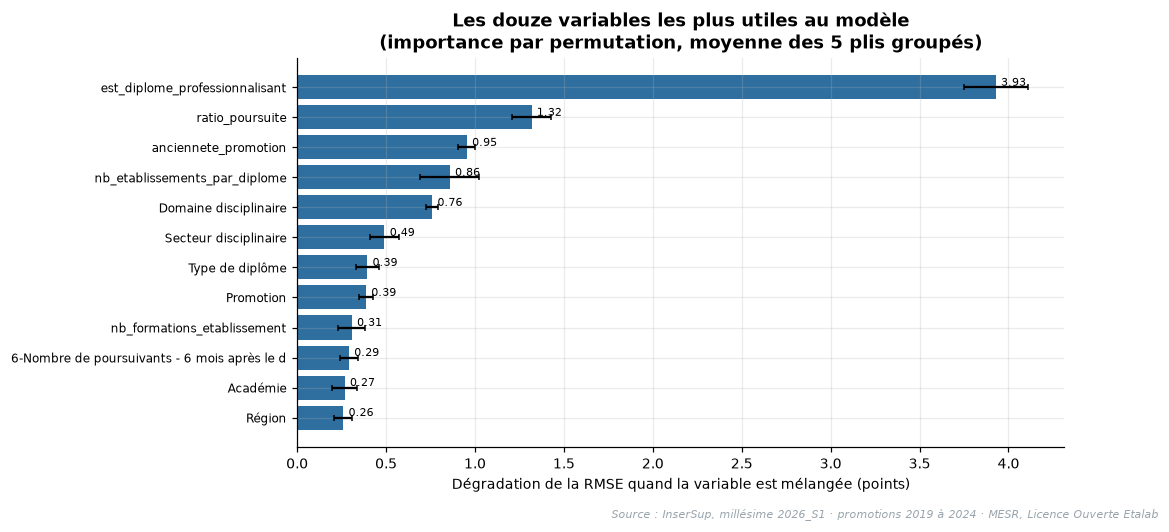

,importance (RMSE),écart-type entre plis,rang
est_diplome_professionnalisant,3.928,0.181,1
ratio_poursuite,1.318,0.110,2
anciennete_promotion,0.954,0.047,3
nb_etablissements_par_diplome,0.858,0.165,4
Domaine disciplinaire,0.759,0.032,5
Secteur disciplinaire,0.491,0.083,6
Type de diplôme,0.394,0.065,7
Promotion,0.387,0.039,8
nb_formations_etablissement,0.307,0.077,9
6-Nombre de poursuivants - 6 mois après le diplôme,0.291,0.052,10


In [4]:
synthese = pd.DataFrame({
    'importance (RMSE)': importances.mean(axis=1).round(3),
    'écart-type entre plis': importances.std(axis=1).round(3),
}).sort_values('importance (RMSE)', ascending=False)
synthese['rang'] = range(1, len(synthese) + 1)

sommet = synthese.head(12).iloc[::-1]
positions = np.arange(len(sommet))
figure, axes = plt.subplots(figsize=(9, 4.6))
axes.barh(positions, sommet['importance (RMSE)'], xerr=sommet['écart-type entre plis'],
          color=COULEUR, capsize=2)
axes.set_yticks(positions)
axes.set_yticklabels([nom[:44] for nom in sommet.index], fontsize=8)
axes.set_xlabel('Dégradation de la RMSE quand la variable est mélangée (points)')
axes.set_title('Les douze variables les plus utiles au modèle\n'
               '(importance par permutation, moyenne des 5 plis groupés)')
for position, valeur in enumerate(sommet['importance (RMSE)']):
    axes.text(valeur + 0.03, position + 0.15, f'{valeur:.2f}', va='center', fontsize=7.5)
annoter_source()
plt.savefig(FIGURE_PATH / 'fig15_importance_variables.png')
plt.show()
synthese

### Confrontation avec les hypothèses de l'étape 2

| Hypothèse de l'étape 2 | Verdict |
|---|---|
| 1. Le ratio de poursuite d'études est le prédicteur numérique le plus prometteur | **Confirmée** : 2e variable du modèle, 1re parmi les numériques |
| 2. Le secteur disciplinaire doit primer sur le domaine | **Infirmée** : domaine 0,76, secteur 0,49 |
| 3. La promotion apporte un effet de niveau, pas une tendance | **Nuancée** : c'est la forme ordonnée qui sert (0,95), pas l'encodage par année (0,39) |
| 4. L'erreur sera plus forte sur les petits effectifs | **Confirmée**, section 4 |
| 5. Un $R^2$ autour de 0,5 est un plafond réaliste | **Confirmée** : 0,50 en validation, 0,48 sur le test |

**Les quatre premières places sont tenues par des variables créées.**
`est_diplome_professionnalisant` domine nettement (3,93 points de RMSE), devant
`ratio_poursuite`, `anciennete_promotion` et `nb_etablissements_par_diplome`. Le feature
engineering de l'étape 3 porte l'essentiel du signal.

**Hypothèse 2, infirmée.** L'EDA avait mesuré un eta² de 0,194 pour le secteur contre
0,083 pour le domaine. La permutation dit l'inverse. Les deux variables sont redondantes,
le domaine étant l'agrégat du secteur : mélanger l'une laisse l'autre disponible, et le
modèle compense. Le modèle préfère couper sur les 4 modalités du domaine, plus robustes,
que sur les 49 du secteur.

**La corrélation linéaire ne dit pas tout.** `nb_etablissements_par_diplome` n'a qu'une
corrélation de 0,02 avec la cible, mais arrive 4e. Elle sépare les diplômes nationaux très
répandus des diplômes propres à un établissement, une distinction qui n'agit pas de façon
monotone. Écarter cette variable sur sa seule corrélation aurait été une erreur.

**Ce qui n'a pas servi.** `promotion_choc_sanitaire` (0,000) et `tranche_effectif`
(0,001) ferment le classement : l'indicateur 2020 fait doublon avec la promotion, et le
découpage en tranches n'apporte rien que les effectifs ne portent déjà. Une partie du
feature engineering n'a donc pas servi, et le dire vaut mieux que de le masquer.

## 4. Erreurs par groupe

Une erreur moyenne globale cache des disparités. On regarde où le modèle se trompe, sur les
prédictions hors pli, en ne commentant que les groupes d'au moins 30 formations.

--- MAE par Promotion (groupes de 30 formations minimum) ---
           formations    MAE  biais_moyen
Promotion                                
2020             2178  10.75        -0.18
2019             2139  10.19         0.03
2024             2353  10.12        -0.24
2023             2294  10.04         0.23
2021             2360   9.80         0.49
2022             2394   9.67         0.40

--- MAE par Type de diplôme (groupes de 30 formations minimum) ---
                                                      formations    MAE  biais_moyen
Type de diplôme                                                                     
Diplôme visé niveau bac + 5                                   56  16.00        -3.14
Diplôme visé niveau bac + 3                                  117  14.84        -2.71
Diplôme visé niveau bac + 3 ou bac + 4 grade licence         115  14.41         1.29
Licence professionnelle                                     1600  11.07         0.68
Diplôme visé niveau bac +

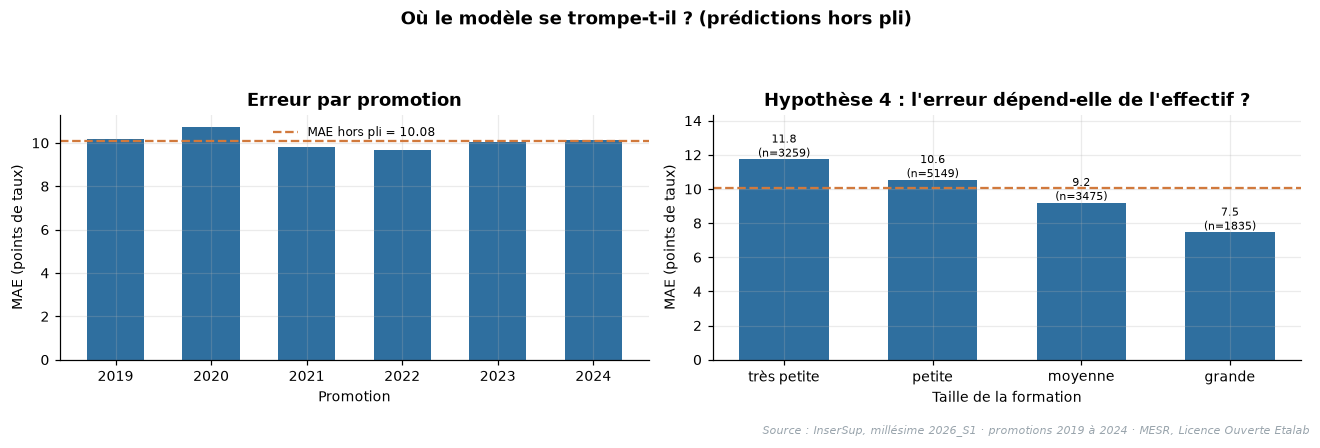

In [5]:
SEUIL_GROUPE = 30

analyse = X_train.copy()
analyse['erreur_absolue'] = np.abs(residus)
analyse['residu'] = residus

groupes = {}
for colonne in ['Promotion', 'Type de diplôme', 'tranche_effectif', 'Domaine disciplinaire']:
    resume = (analyse.groupby(colonne)
              .agg(formations=('erreur_absolue', 'size'),
                   MAE=('erreur_absolue', 'mean'),
                   biais_moyen=('residu', 'mean'))
              .query(f'formations >= {SEUIL_GROUPE}')
              .sort_values('MAE', ascending=False)
              .round(2))
    groupes[colonne] = resume
    print(f'--- MAE par {colonne} (groupes de {SEUIL_GROUPE} formations minimum) ---')
    print(resume.to_string())
    print()

mae_globale = np.abs(residus).mean()
figure, axes = plt.subplots(1, 2, figsize=(12, 3.8))

par_promotion = groupes['Promotion'].sort_index()
axes[0].bar(par_promotion.index.astype(str), par_promotion['MAE'], color=COULEUR, width=0.6)
axes[0].axhline(mae_globale, color=COULEUR_ALT, linestyle='--',
                label=f'MAE hors pli = {mae_globale:.2f}')
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('MAE (points de taux)')
axes[0].set_title('Erreur par promotion')
axes[0].legend(frameon=False, fontsize=8)

par_taille = groupes['tranche_effectif'].reindex(
    ['très petite (≤ 25)', 'petite (26-45)', 'moyenne (46-90)', 'grande (> 90)']).dropna()
axes[1].bar(range(len(par_taille)), par_taille['MAE'], color=COULEUR, width=0.6)
axes[1].set_xticks(range(len(par_taille)))
axes[1].set_xticklabels([nom.split(' (')[0] for nom in par_taille.index])
axes[1].axhline(mae_globale, color=COULEUR_ALT, linestyle='--')
axes[1].set_xlabel('Taille de la formation')
axes[1].set_ylabel('MAE (points de taux)')
axes[1].set_title("Hypothèse 4 : l'erreur dépend-elle de l'effectif ?")
axes[1].set_ylim(0, par_taille['MAE'].max() * 1.22)
for position, (valeur, effectif) in enumerate(zip(par_taille['MAE'], par_taille['formations'])):
    axes[1].text(position, valeur + 0.15, f'{valeur:.1f}\n(n={effectif:.0f})',
                 ha='center', fontsize=7.5)

figure.suptitle('Où le modèle se trompe-t-il ? (prédictions hors pli)',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig16_erreurs_par_groupe.png')
plt.show()

**L'hypothèse 4 est nettement confirmée.** L'erreur passe de 7,5 points sur les grandes
formations (plus de 90 sortants) à 11,8 sur les très petites (25 ou moins) : un rapport de
1,6. C'est mécanique : sur 20 diplômés, un seul individu vaut 5 points de taux.

**La promotion 2020 reste la plus difficile** (10,75), conséquence d'un choc conjoncturel
que rien dans les variables ne permet d'anticiper.

**Les diplômes visés des écoles privées sont les plus mal prédits**, entre 14 et 16 points
d'erreur, mais sur de petits groupes (33 à 117 formations). Ce sont aussi les formations
dont l'établissement est le plus souvent inconnu de l'apprentissage. À l'inverse, le master
MEEF est très bien prédit (6,7) : un débouché quasi unique, le concours de l'enseignement.

## 5. Robustesse temporelle

Le score groupé répond à : « sais-je estimer une formation que je n'ai jamais vue ? ». Une
autre question compte : « connaissant le passé, sais-je prévoir l'avenir ? ». On la pose
sur le seul apprentissage : le modèle est entraîné sur les promotions 2019 à 2022, puis
évalué sur les promotions 2023 et 2024. Le test reste fermé.

In [6]:
apprentissage = df.loc[index_train]
passe = apprentissage['Promotion'] <= 2022
futur = apprentissage['Promotion'] >= 2023

modele_temporel = creer_pipeline(modele_retenu)
modele_temporel.fit(apprentissage.loc[passe, COLONNES_ENTREE], apprentissage.loc[passe, TARGET])
reference_temporelle = creer_pipeline(DummyRegressor(strategy='mean'))
reference_temporelle.fit(apprentissage.loc[passe, COLONNES_ENTREE],
                         apprentissage.loc[passe, TARGET])

scenarios = pd.DataFrame({
    'Validation groupée (hors pli, 2019-2024)': mesurer(vraies, oof),
    'Temporelle : 2019-2022 → 2023-2024': mesurer(
        apprentissage.loc[futur, TARGET],
        modele_temporel.predict(apprentissage.loc[futur, COLONNES_ENTREE])),
    'Référence naïve, même découpage temporel': mesurer(
        apprentissage.loc[futur, TARGET],
        reference_temporelle.predict(apprentissage.loc[futur, COLONNES_ENTREE])),
}).T
print(f'Entraînement temporel : {int(passe.sum())} lignes · évaluation : {int(futur.sum())} lignes')
scenarios

Entraînement temporel : 9071 lignes · évaluation : 4647 lignes


,MAE,RMSE,R²
"Validation groupée (hors pli, 2019-2024)",10.084,13.097,0.500
Temporelle : 2019-2022 → 2023-2024,10.005,13.097,0.448
"Référence naïve, même découpage temporel",14.049,17.636,-0.001


**Prévoir l'avenir coûte surtout en $R^2$.** Entraîné sur 2019-2022 et évalué sur
2023-2024, le modèle garde une MAE du même ordre (10,0), mais son $R^2$ tombe de 0,50 à
0,45. Il bat toujours largement la référence naïve (14,0). Les deux scores mesurent deux
choses différentes, et se présentent ensemble : le score groupé vaut pour une formation
inconnue d'une année observée, le score temporel pour une promotion future.

Ici, les formations évaluées en 2023-2024 ont souvent déjà été vues en 2019-2022 : le
scénario temporel mesure la prévision pour des formations connues, pas pour des formations
nouvelles. Les deux difficultés ne se cumulent donc pas dans ce chiffre.

## 6. Évaluation finale : l'unique ouverture du jeu de test

Le modèle est entraîné sur tout l'apprentissage, puis appliqué une fois au jeu de test :
des formations dont **aucune promotion** n'a été vue à l'entraînement. Une référence naïve
est mesurée sur le même test. La cellule ne fait que mesurer : rien n'est ajusté, rien
n'est choisi après elle.

In [7]:
modele_final = creer_pipeline(modele_retenu)
modele_final.fit(X_train, y_train)
reference = creer_pipeline(DummyRegressor(strategy='mean')).fit(X_train, y_train)

# Seule construction du jeu de test du projet.
X_test = df.loc[index_test, COLONNES_ENTREE]
y_test = df.loc[index_test, TARGET]
predictions = modele_final.predict(X_test)
predictions_reference = reference.predict(X_test)

METRIQUES_TEST = mesurer(y_test, predictions)
erreurs = np.abs(y_test.to_numpy() - predictions)
erreurs_reference = np.abs(y_test.to_numpy() - predictions_reference)
RESUME_TEST = {
    'formations': int(identifiant_formation(df.loc[index_test]).nunique()),
    'lignes': int(len(y_test)),
    'mae_reference': round(float(erreurs_reference.mean()), 3),
    'reduction_erreur': round(float(1 - erreurs.mean() / erreurs_reference.mean()), 3),
    'part_a_5_points': round(float((erreurs <= 5).mean()), 3),
    'part_a_5_points_reference': round(float((erreurs_reference <= 5).mean()), 3),
    'ratees_15_points': int((erreurs > 15).sum()),
    'ratees_15_points_reference': int((erreurs_reference > 15).sum()),
}
del X_test, y_test  # le jeu de test ne resservira pas

resultat_test = pd.DataFrame({'Référence naïve': mesurer(
    df.loc[index_test, TARGET], predictions_reference), NOM_MODELE: METRIQUES_TEST})
print(f"Sur les {RESUME_TEST['lignes']} lignes de test ({RESUME_TEST['formations']} formations "
      f"jamais vues) :")
print(f"  · erreur moyenne du modèle : {METRIQUES_TEST['MAE']:.2f} points de taux d'emploi")
print(f"  · erreur moyenne de la référence : {RESUME_TEST['mae_reference']:.2f} points")
print(f"  · réduction de l'erreur : {100 * RESUME_TEST['reduction_erreur']:.0f} %")
print(f"  · prédites à moins de 5 points près : {100 * RESUME_TEST['part_a_5_points']:.0f} % "
      f"(contre {100 * RESUME_TEST['part_a_5_points_reference']:.0f} % pour la référence)")
print(f"  · ratées de plus de 15 points : {RESUME_TEST['ratees_15_points']} "
      f"(contre {RESUME_TEST['ratees_15_points_reference']})")
resultat_test

Sur les 3347 lignes de test (990 formations jamais vues) :
  · erreur moyenne du modèle : 10.09 points de taux d'emploi
  · erreur moyenne de la référence : 14.77 points
  · réduction de l'erreur : 32 %
  · prédites à moins de 5 points près : 33 % (contre 21 % pour la référence)
  · ratées de plus de 15 points : 779 (contre 1445)


,Référence naïve,Gradient boosting
MAE,14.765,10.090
RMSE,18.215,13.081
R²,-0.000,0.484


**Le score de test confirme la validation, à 0,006 point près.** 10,09 de MAE sur le test,
contre 10,08 en validation croisée groupée. C'est le signe que le protocole mesure ce qu'il
prétend mesurer : avec des plis groupés, la validation n'est plus optimiste, et le test
n'apporte pas de mauvaise surprise.

Sur 990 formations dont aucune promotion n'a été vue à l'entraînement :

- erreur moyenne de **10,09 points** de taux d'emploi, contre 14,77 pour la référence
  naïve, soit **32 % d'erreur en moins** ;
- **33 %** des lignes prédites à moins de 5 points près, contre 21 % pour la référence ;
- **779** lignes ratées de plus de 15 points, contre 1 445 ;
- $R^2$ de **0,484**.

Ce score est plus faible que celui annoncé par la première version du projet (9,58), et
c'est le bon : l'ancien mesurait surtout la capacité à reconnaître des formations déjà
vues.

## 7. Limites et biais

**Ce que le modèle prédit.** Un taux agrégé de formation, jamais l'employabilité d'un
individu.

**Erreur moyenne.** Environ 10 points de taux d'emploi sur une formation inconnue. Sur une
formation annoncée à 60 %, la réalité se situe le plus souvent entre 50 % et 70 %. C'est
utilisable pour situer une formation face à ses comparables, pas pour classer deux
formations proches, ni pour décider d'une fermeture.

**Erreur très inégale.** Rapport de 1,6 entre petites et grandes formations, et prédiction
ramenée vers la moyenne sur les taux extrêmes : jusqu'à 15 à 23 points d'écart moyen sur
les formations qui insèrent très bien ou très mal.

**Variables contemporaines de la cible.** Le nombre de sortants et de poursuivants vient de
la même enquête à 6 mois que la cible. Le modèle prédit au moment de l'enquête, pas avant
la sortie de la promotion.

**Biais de sélection.** Le seuil de publication de 20 sortants exclut structurellement les
petites formations : le modèle n'a jamais vu de formation de 10 diplômés.

**Biais de représentation.** Régions, disciplines et établissements privés sont
inégalement représentés ; les diplômes visés des écoles privées sont les plus mal prédits.

**Ce que le modèle ne peut pas dire.** `Genre`, `Nationalité` et `Régime d'inscription`
ne font pas partie du jeu de modélisation. Le modèle ne peut ni produire ni écarter une
conclusion sur des disparités de genre ou de nationalité.

**Risque d'usage.** Appliqué à une décision d'orientation ou d'allocation de moyens, ce
modèle reproduirait les écarts existants entre disciplines et territoires en leur donnant
l'apparence d'une prédiction objective. Son usage raisonnable est descriptif, pas
prescriptif.

## 8. Livraison : pipeline sauvegardée et prédiction sur une donnée brute

La pipeline complète est sauvegardée : agrégats de contexte, encodage **et** modèle. Les
tables d'agrégats apprises sur l'apprentissage sont donc embarquées dans la pipeline
elle-même : il n'y a plus de référentiel séparé, et plus d'écart possible entre ce que le
modèle a vu à l'entraînement et ce qu'il reçoit à l'inférence.

Le contrôle de rechargement porte sur des lignes d'apprentissage : le test ne resservira
pas.

In [8]:
joblib.dump({
    'pipeline': modele_final,
    'modele': NOM_MODELE,
    'colonnes_entree': COLONNES_ENTREE,
    'features': FEATURES,
    'cible': TARGET,
    'metriques_test': METRIQUES_TEST,
    'resume_test': RESUME_TEST,
    'metriques_validation': mesurer(vraies, oof),
    'importances_validation': synthese['importance (RMSE)'].to_dict(),
    # Relevés du diagnostic en validation croisée, repris par la fiche modèle (étape 7).
    'releves_validation': {
        'mae_petites_formations': float(groupes['tranche_effectif'].loc['très petite (≤ 25)', 'MAE']),
        'mae_grandes_formations': float(groupes['tranche_effectif'].loc['grande (> 90)', 'MAE']),
        'mae_promotion_2020': float(groupes['Promotion'].loc[2020, 'MAE']),
        'r2_temporel': float(scenarios.iloc[1]['R²']),
        'mae_temporelle': float(scenarios.iloc[1]['MAE']),
        'residu_taux_hauts': round(float(residus[vraies >= 85].mean()), 1),
        'residu_taux_bas': round(float(residus[vraies <= 25].mean()), 1),
    },
}, FICHIER_MODELE, compress=3)
print('Modèle sauvegardé :', FICHIER_MODELE.relative_to(PROJECT_PATH))
print('Taille du fichier :', round(FICHIER_MODELE.stat().st_size / 1024**2, 2), 'Mo')

# Contrôle de non-régression, sur des lignes d'apprentissage.
livrable = joblib.load(FICHIER_MODELE)
echantillon = X_train.sample(500, random_state=0)
assert np.allclose(modele_final.predict(echantillon),
                   livrable['pipeline'].predict(echantillon)), \
    'Le modèle rechargé ne reproduit pas les prédictions'
print('Modèle rechargé : prédictions identiques sur 500 lignes d\'apprentissage.')

Modèle sauvegardé : modeles/modele_final.joblib
Taille du fichier : 0.26 Mo
Modèle rechargé : prédictions identiques sur 500 lignes d'apprentissage.


In [9]:
from modeles.inference import predire, preparer_ligne_brute

# 1. Plus d'écart entre entraînement et inférence : une ligne brute passée par le module
# d'inférence reçoit exactement la prédiction de la pipeline sur la même ligne.
brutes = df.loc[index_train].sample(200, random_state=1)
via_inference = np.array([
    livrable['pipeline'].predict(preparer_ligne_brute(ligne, livrable))[0]
    for ligne in brutes.to_dict('records')])
directes = livrable['pipeline'].predict(brutes[COLONNES_ENTREE])
assert np.allclose(via_inference, directes), 'Écart entre inférence et entraînement'
print('Inférence depuis une ligne brute : identique à la pipeline sur 200 lignes.')
print()

# 2. Démonstration sur une formation au format de la source, avec un diplôme inconnu.
ligne_brute = {
    'Région': 'Bretagne',
    'Académie': 'Rennes',
    'Type de diplôme': 'Licence professionnelle',
    'Domaine disciplinaire': 'Sciences, technologies, santé',
    'Discipline': 'Sciences fondamentales et applications',
    'Secteur disciplinaire': 'Informatique',
    'Promotion': 2024,
    CODE_UAI: '0350936C',
    CODE_SISE: '99999',          # diplôme inconnu : le repli doit fonctionner
    SORTANTS: 48,
    POURSUIVANTS: 6,
}
resultat = predire(livrable, ligne_brute)
print('Donnée brute soumise :')
for cle, valeur in ligne_brute.items():
    print(f'  {cle} : {valeur}')
print()
print(f"Prédiction : {resultat['prediction']} % de taux d'emploi salarié à 6 mois")
print(f"Intervalle indicatif à ± la MAE de test : {resultat['intervalle'][0]} % à "
      f"{resultat['intervalle'][1]} %")
print(f"Variables retombées sur leur valeur par défaut : {resultat['replis'] or 'aucune'}")

Inférence depuis une ligne brute : identique à la pipeline sur 200 lignes.

Donnée brute soumise :
  Région : Bretagne
  Académie : Rennes
  Type de diplôme : Licence professionnelle
  Domaine disciplinaire : Sciences, technologies, santé
  Discipline : Sciences fondamentales et applications
  Secteur disciplinaire : Informatique
  Promotion : 2024
  Code UAI de l'établissement : 0350936C
  Code du diplôme SISE : 99999
  6-Nombre de sortants - 6 mois après le diplôme : 48
  6-Nombre de poursuivants - 6 mois après le diplôme : 6

Prédiction : 63.3 % de taux d'emploi salarié à 6 mois
Intervalle indicatif à ± la MAE de test : 53.2 % à 73.4 %
Variables retombées sur leur valeur par défaut : ['nb_formations_etablissement', 'nb_etablissements_par_diplome']


## Conclusion de l'étape 5c

Le gradient boosting retenu à l'étape 5b réduit l'erreur d'un tiers par rapport à une
prédiction constante, **sur des formations qu'il n'a jamais vues** : 10,09 points de MAE
contre 14,77, pour un $R^2$ de 0,48. Le score de test rejoint celui de la validation
groupée, ce qui valide le protocole.

Ce qui compte autant que ce chiffre, c'est de savoir où il ne tient pas : sur les **petites
formations**, sur les **taux extrêmes**, sur la **promotion 2020**, sur les **diplômes
visés des écoles privées**, et en **prévision temporelle**, où le $R^2$ baisse à 0,45.

Le livrable est une pipeline unique de 0,26 Mo : agrégats, encodage et modèle. Elle prend
une ligne au format de la source, rend une prédiction identique à celle de l'entraînement,
et signale les cas où elle a dû se replier sur une valeur par défaut.

## Utilisation de l'IA sur cette étape

Cette étape est issue de la révision demandée par la formatrice, menée avec Claude Code.

| Prompt utilisé | Ce que l'IA a produit | Vérification effectuée |
|---|---|---|
| Les quatre retours de la formatrice, collés tels quels | Un plan : transformateur d'agrégats dans la pipeline, découpage groupé, diagnostics en validation croisée, test ouvert une fois | Plan relu et amendé avant exécution : retrait de `part_sortants_etablissement`, choix du modèle par le duel avant le test |
| « Le test ne doit être lu que dans une seule cellule » | Restructuration en 5 / 5b / 5c | Vérifié par un script qui cherche `X_test` et `y_test` dans tous les notebooks |
| « Comment prouver qu'il n'y a plus d'écart entre entraînement et inférence ? » | Comparer `predire` et `pipeline.predict` sur les mêmes lignes | Ajouté comme `assert` exécutable, sur 200 lignes brutes |